<a href="https://colab.research.google.com/github/i-Abrajan/Example_Tarea/blob/main/yahoo_fin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# CELDA 1: Instalación
# ============================================================
!pip install yfinance --quiet

In [ ]:
# ============================================================
# CELDA 2: Importaciones
# ============================================================
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
from pathlib import Path

In [ ]:
# ============================================================
# CELDA 3: Parámetros (formulario interactivo de Colab)
# ============================================================
#@title Configuración de la descarga { display-mode: "form" }

ticker = "AAPL"  #@param {type:"string"}
fecha_inicio = "2021-01-01"  #@param {type:"date"}
fecha_fin = "2023-11-30"  #@param {type:"date"}
intervalo = "1d"  #@param ["1d", "1wk", "1mo"]
guardar_en_drive = True  #@param {type:"boolean"}
nombre_archivo = "datos_yahoo.csv"  #@param {type:"string"}

In [ ]:
# ============================================================
# CELDA 4: Función de descarga
# ============================================================
def descargar_datos(ticker: str, inicio: str, fin: str, intervalo: str = "1d") -> pd.DataFrame:
    """
    Descarga datos históricos de Yahoo Finance.

    Parámetros
    ----------
    ticker : str
        Símbolo bursátil (ej. 'AAPL', 'MSFT', 'WALMEX.MX').
    inicio, fin : str
        Fechas en formato 'YYYY-MM-DD'.
    intervalo : str
        '1d' diario, '1wk' semanal, '1mo' mensual.

    Retorna
    -------
    DataFrame con columnas Open, High, Low, Close, Volume.
    """
    df = yf.download(
        tickers=ticker,
        start=inicio,
        end=fin,
        interval=intervalo,
        progress=False,
        auto_adjust=True,
    )

    if df.empty:
        raise ValueError(f"No se obtuvieron datos para {ticker}. Revisa el ticker o las fechas.")

    # Aplanar columnas si yfinance devuelve MultiIndex
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df.index.name = "Fecha"
    return df

In [ ]:
# ============================================================
# CELDA 5: Descarga y validación
# ============================================================
df = descargar_datos(ticker, fecha_inicio, fecha_fin, intervalo)

print(f"Ticker: {ticker}")
print(f"Periodo: {fecha_inicio} a {fecha_fin}")
print(f"Observaciones: {df.shape[0]} filas, {df.shape[1]} columnas")
print(f"Rango real de fechas: {df.index.min().date()} a {df.index.max().date()}")
print("\nPrimeras 5 filas:")
df.head()

Ticker: AAPL
Periodo: 2021-01-01 a 2023-11-30
Observaciones: 732 filas, 5 columnas
Rango real de fechas: 2021-01-04 a 2023-11-29

Primeras 5 filas:


Price,Close,High,Low,Open,Volume
Fecha,,,,,
2021-01-04,125.856682,129.941356,123.279444,129.853831,143301900
2021-01-05,127.412758,128.122724,124.903597,125.350973,97664900
2021-01-06,123.123856,127.451673,122.909895,124.213106,155088000
2021-01-07,127.325249,128.015760,124.349271,124.835543,109578200
2021-01-08,128.424179,128.988255,126.654145,128.793735,105158200


In [ ]:
# ============================================================
# CELDA 6: Variables derivadas (features básicos para ciencia de datos)
# ============================================================
df["Rendimiento"] = df["Close"].pct_change()
df["Media_Movil_20"] = df["Close"].rolling(window=20).mean()
df["Media_Movil_50"] = df["Close"].rolling(window=50).mean()
df["Volatilidad_20"] = df["Rendimiento"].rolling(window=20).std()

print("Estadísticos descriptivos del precio de cierre:")
df["Close"].describe()

Estadísticos descriptivos del precio de cierre:


,Close
count,732.000000
mean,152.138934
std,19.226344
min,113.334122
25%,138.636902
50%,149.097672
75%,168.673264
max,193.912491


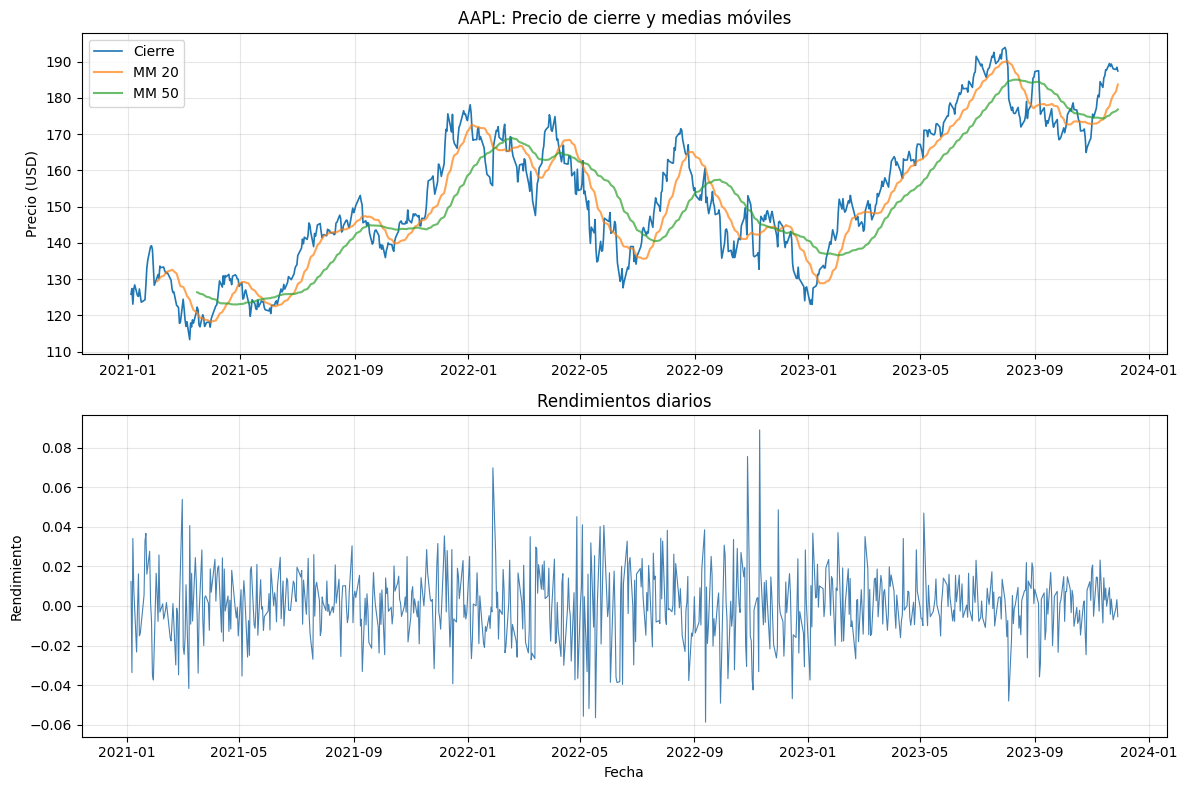

In [ ]:
# ============================================================
# CELDA 7: Visualización rápida de validación
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(df.index, df["Close"], label="Cierre", linewidth=1.2)
axes[0].plot(df.index, df["Media_Movil_20"], label="MM 20", alpha=0.7)
axes[0].plot(df.index, df["Media_Movil_50"], label="MM 50", alpha=0.7)
axes[0].set_title(f"{ticker}: Precio de cierre y medias móviles")
axes[0].set_ylabel("Precio (USD)")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(df.index, df["Rendimiento"], color="steelblue", linewidth=0.8)
axes[1].set_title("Rendimientos diarios")
axes[1].set_ylabel("Rendimiento")
axes[1].set_xlabel("Fecha")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELDA 8: Guardado y descarga al disco local
# ============================================================
from google.colab import files

ruta = Path(nombre_archivo)
df.to_csv(ruta)

print(f"Archivo generado: {ruta.name}")
print(f"Tamaño: {ruta.stat().st_size / 1024:.1f} KB")
print("Iniciando descarga al disco local...")

files.download(ruta)

Archivo generado: datos_yahoo.csv
Tamaño: 123.1 KB
Iniciando descarga al disco local...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!git status

fatal: not a git repository (or any of the parent directories): .git
